In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_11004\148431093.py:6: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv('datasets\madalena_processed_30min\E_147.csv')


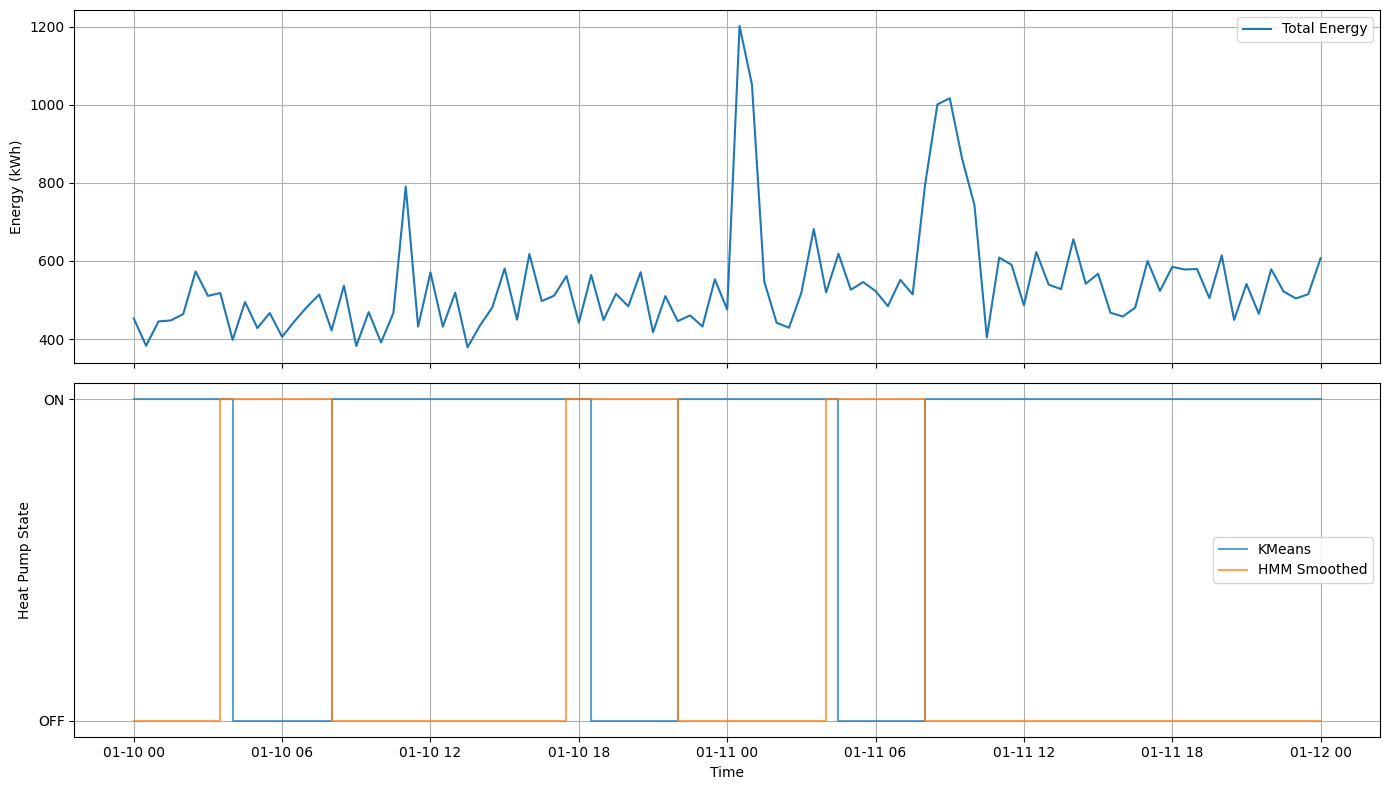

In [37]:
import numpy as np
from sklearn.cluster import KMeans
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('datasets\madalena_processed_30min\E_147.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df = df.sort_index()

df['delta_Tin'] = df['Tin'].diff()
df['delta_T'] = df['Tin'] - df['Tout']
df['delta_energy'] = df['total_energy'].diff()
df['heating_load'] = np.maximum(0, df['Tin'] - df['Tout'])
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek

df.fillna(0, inplace=True)

features = ['delta_Tin', 'delta_energy', 'heating_load', 'delta_T']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_means = df.groupby('cluster')['delta_energy'].mean()
on_cluster = cluster_means.idxmax()
df['heat_pump_active_kmeans'] = (df['cluster'] == on_cluster).astype(int)

df2 = df.copy()
df2 = df2[['total_energy', 'Tin', 'Tout', 'heat_pump_active_kmeans']]
df2.to_csv('datasets/madalena_heat_test.csv')

obs = X_scaled

model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, random_state=42)
model.fit(obs)

hidden_states = model.predict(obs)

state_means = model.means_[:, 1]  
on_state = np.argmax(state_means)

df['heat_pump_hmm'] = (hidden_states == on_state).astype(int)

start_date = pd.to_datetime("2025-01-10")
end_date = start_date + pd.Timedelta(days=2)

mask = (df.index >= start_date) & (df.index <= end_date)
df_zoom = df.loc[mask]

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axs[0].plot(df_zoom.index, df_zoom['total_energy'], label='Total Energy', color='tab:blue')
axs[0].set_ylabel('Energy (kWh)')
axs[0].legend()
axs[0].grid(True)

axs[1].step(df_zoom.index, df_zoom['heat_pump_active_kmeans'], label='KMeans', where='post', alpha=0.7)
axs[1].step(df_zoom.index, df_zoom['heat_pump_hmm'], label='HMM Smoothed', where='post', alpha=0.7)
axs[1].set_ylabel('Heat Pump State')
axs[1].set_xlabel('Time')
axs[1].set_yticks([0, 1])
axs[1].set_yticklabels(['OFF', 'ON'])
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

                     total_energy       Tout        Tin         RH  hour  \
timestamp                                                                  
2025-03-10 00:00:00        233.53  10.302222  21.251609  35.341710     0   
2025-03-10 00:30:00        321.60   9.902222  21.190664  35.333886     0   
2025-03-10 01:00:00        341.17   9.502222  21.037998  35.472944     1   
2025-03-10 01:30:00        302.17   9.102223  20.991165  35.471021     1   
2025-03-10 02:00:00        325.70   8.800000  20.857942  35.590056     2   

                     hour_sin  hour_cos   max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                                ...   
2025-03-10 00:00:00  0.000000  1.000000  17.799999       7.4  12.748310  ...   
2025-03-10 00:30:00  0.000000  1.000000  17.799999       7.4  12.754607  ...   
2025-03-10 01:00:00  0.258819  0.965926  17.799999       7.4  12.760857  ...   
2025-03-10 01:30:00  0.258819  0.965926  17.799999       7.4  12.76

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

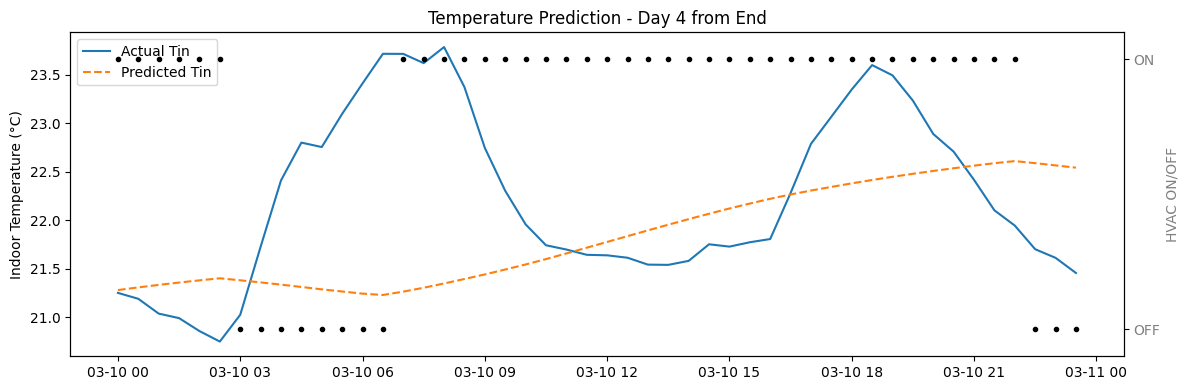

                     total_energy  Tout        Tin         RH  hour  hour_sin  \
timestamp                                                                       
2025-03-11 00:00:00        227.10   8.5  21.324997  40.284667     0  0.000000   
2025-03-11 00:30:00        258.10   8.4  21.300219  40.228603     0  0.000000   
2025-03-11 01:00:00        274.37   8.3  21.219553  40.203087     1  0.258819   
2025-03-11 01:30:00        325.93   8.2  21.126960  40.164789     1  0.258819   
2025-03-11 02:00:00        262.43   8.1  21.021818  40.183070     2  0.500000   

                     hour_cos  max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                     ...   
2025-03-11 00:00:00  1.000000      18.4       7.2  12.589757  ...   
2025-03-11 00:30:00  1.000000      18.4       7.2  12.558461  ...   
2025-03-11 01:00:00  0.965926      18.4       7.2  12.533414  ...   
2025-03-11 01:30:00  0.965926      18.4       7.2  12.514618  ...   
2025-03-11 02:00:0

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

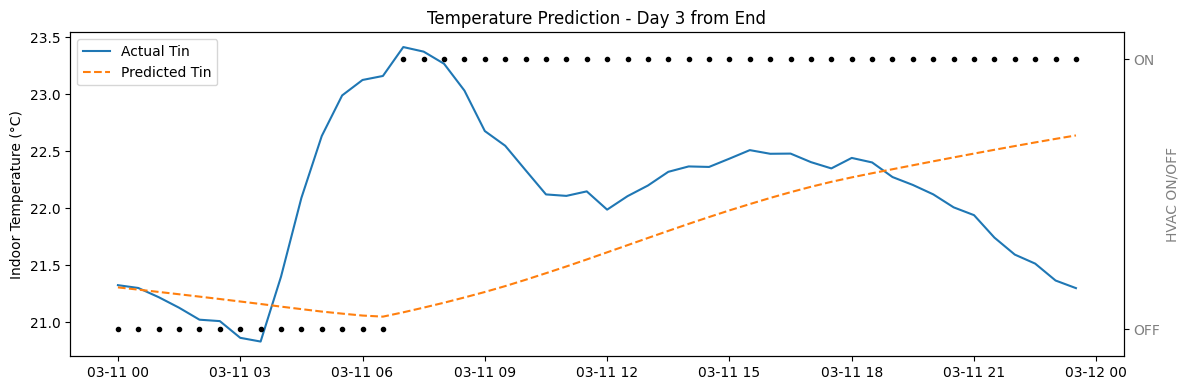

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

                     total_energy       Tout        Tin         RH  hour  \
timestamp                                                                  
2025-03-12 00:00:00        227.23  11.601667  21.225997  40.969451     0   
2025-03-12 00:30:00        221.17  11.102778  21.123830  41.084414     0   
2025-03-12 01:00:00        236.83  10.901111  21.090608  41.039102     1   
2025-03-12 01:30:00        358.73  10.800556  21.017275  41.059745     1   
2025-03-12 02:00:00        885.20  10.800000  21.046331  41.519319     2   

                     hour_sin  hour_cos   max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                                ...   
2025-03-12 00:00:00  0.000000  1.000000  19.099442  7.402222  13.316332  ...   
2025-03-12 00:30:00  0.000000  1.000000  19.099442  7.402222  13.372640  ...   
2025-03-12 01:00:00  0.258819  0.965926  19.099442  7.402222  13.426830  ...   
2025-03-12 01:30:00  0.258819  0.965926  19.099442  7.402222  13.48

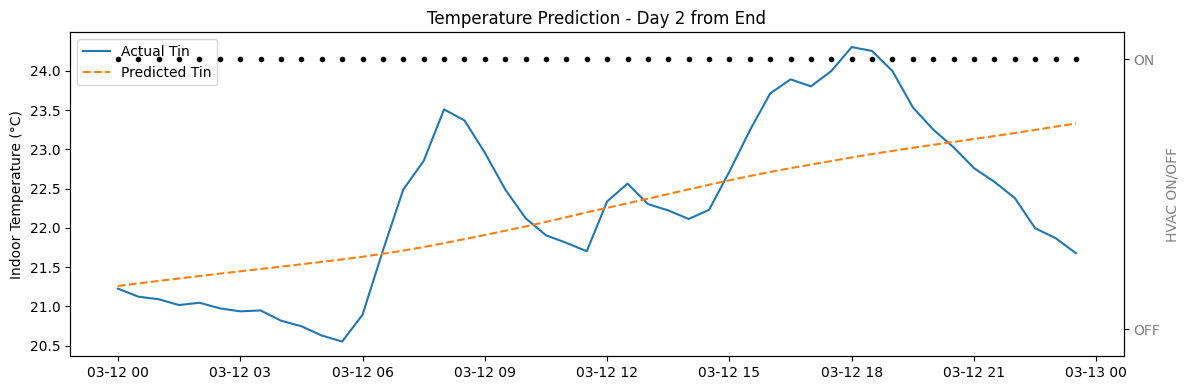

                     total_energy       Tout        Tin         RH  hour  \
timestamp                                                                  
2025-03-13 00:00:00        404.60  15.996667  21.578665  41.523605     0   
2025-03-13 00:30:00       1048.90  15.900555  21.575386  41.765716     0   
2025-03-13 01:00:00        736.30  15.900000  21.422199  41.958989     1   
2025-03-13 01:30:00        226.43  16.098889  21.358998  41.878859     1   
2025-03-13 02:00:00        304.13  16.398333  21.258442  41.871678     2   

                     hour_sin  hour_cos   max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                                ...   
2025-03-13 00:00:00  0.000000  1.000000  19.200001      10.5  14.966748  ...   
2025-03-13 00:30:00  0.000000  1.000000  19.200001      10.5  15.066701  ...   
2025-03-13 01:00:00  0.258819  0.965926  19.200001      10.5  15.170845  ...   
2025-03-13 01:30:00  0.258819  0.965926  19.200001      10.5  15.28

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

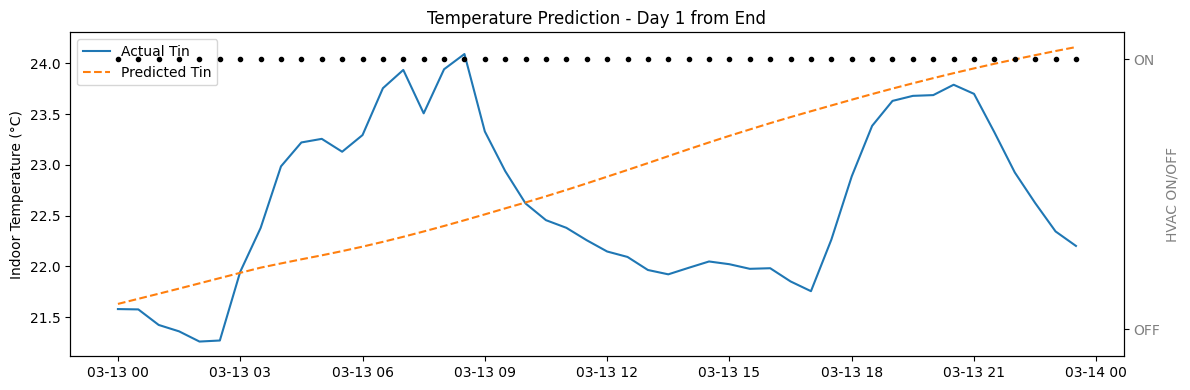

In [5]:
end_date = '2025-03-14'
df = df[df.index < end_date]
df['Tin_next'] = df['Tin'].shift(-1)
df['RH_next'] = df['RH'].shift(-1)
df['Delta_T'] = df['Tin_next'] - df['Tin']
df['Delta_RH'] = df['RH_next'] - df['RH']
df['Tout_minus_Tin'] = df['Tout'] - df['Tin']

# df = df.dropna()

N_test = 48 * 4
df_train = df.iloc[:-N_test]
df_test = df.iloc[-N_test:]

X_temp = df_train[['heat_pump_active_kmeans', 'Tout_minus_Tin']]
y_temp = df_train['Delta_T']
temp_model = LinearRegression().fit(X_temp, y_temp)

X_rh = df_train[['heat_pump_active_kmeans', 'Tout_minus_Tin']]
y_rh = df_train['Delta_RH']
rh_model = LinearRegression().fit(X_rh, y_rh)

N = 48  
start = -1 * (N + 1) 
Tin = df.iloc[start]['Tin']
RH = df.iloc[start]['RH']
schedule = [1] * 24 + [0] * 24 
Tout_series = df.iloc[start:start+N]['Tout'].values

for day in range(4):
    offset = day * 48
    test_chunk = df_test.iloc[offset:offset+48]
    print(test_chunk.head())
    Tin = test_chunk.iloc[0]['Tin']
    RH = test_chunk.iloc[0]['RH']
    timestamps = test_chunk.index.values
    Tout_series = test_chunk['Tout'].values
    HVAC_series =  test_chunk['heat_pump_active_kmeans'].values

    tin_forecast, rh_forecast = [], []
    for i in range(48):
        hvac = HVAC_series[i]
        Tout = Tout_series[i]
        delta_T = temp_model.predict([[hvac, Tout - Tin]])[0]
        delta_RH = rh_model.predict([[hvac, Tout - Tin]])[0]
        Tin += delta_T
        RH += delta_RH
        tin_forecast.append(Tin)
        rh_forecast.append(RH)

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(timestamps, test_chunk['Tin'].values, label='Actual Tin', color='tab:blue')
    ax1.plot(timestamps, tin_forecast, '--', label='Predicted Tin', color='tab:orange')
    ax1.set_ylabel('Indoor Temperature (°C)', color='black')
    ax1.tick_params(axis='y')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(timestamps, HVAC_series, 'ko', label='HVAC Schedule', markersize=3)
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_ylabel('HVAC ON/OFF', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['OFF', 'ON'])

    # plt.title(f'Temperature Forecast vs Actual + HVAC Schedule (Day {4 - day_index_from_end})')
    plt.title(f'Temperature Prediction - Day {4 - day} from End')
    plt.xlabel('Time')
    fig.tight_layout()
    plt.show()
    # plt.figure(figsize=(12, 6))
    # plt.subplot(2, 1, 1)
    # plt.plot(timestamps, test_chunk['Tin'].values, label='Actual Tin')
    # plt.plot(timestamps, tin_forecast, '--', label='Predicted Tin')
    # plt.ylabel('Temperature (°C)')
    # plt.legend()

    # plt.subplot(2, 1, 2)
    # plt.plot(timestamps, test_chunk['RH'].values, label='Actual RH')
    # plt.plot(timestamps, rh_forecast, '--', label='Predicted RH')
    # plt.ylabel('Relative Humidity (%)')
    # plt.xlabel('Time')
    # plt.legend()

    # plt.tight_layout()
    # plt.show()

# tin_forecast = []
# rh_forecast = []

# for i in range(N):
#     hvac = schedule[i]
#     Tout = Tout_series[i]
#     delta_T = temp_model.predict([[hvac, Tout - Tin]])[0]
#     delta_RH = rh_model.predict([[hvac, Tout - Tin]])[0]
#     Tin += delta_T
#     RH += delta_RH
#     tin_forecast.append(Tin)
#     rh_forecast.append(RH)

# print("Tin forecast:", tin_forecast)
# print("RH forecast: ", rh_forecast)

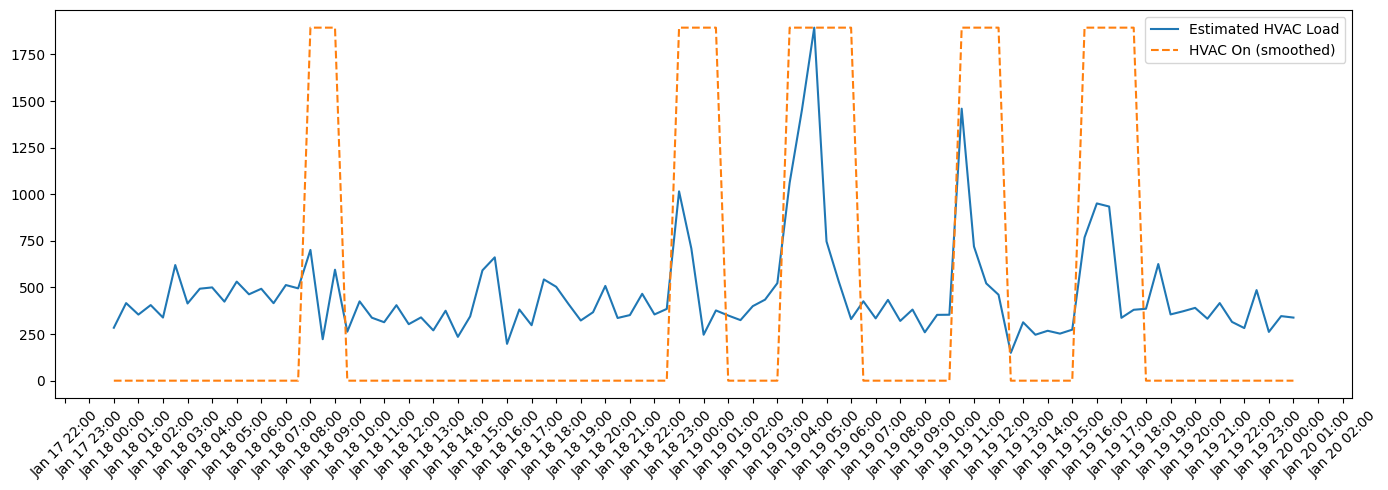

In [41]:
import pandas as pd
import numpy as np
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['hour'] = df.index.hour
df['day'] = df.index.dayofyear

mild_mask = (df['Tout'] > 15) & (df['Tout'] < 20)
baseline_load = df[mild_mask].groupby('hour')['total_energy'].mean()

df['baseline'] = df['hour'].map(baseline_load)
df['residual_load'] = df['total_energy'] - df['baseline']
df['residual_load'] = df['residual_load'].fillna(0)

features = ['Tin', 'total_energy', 'Tout']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
y = df['residual_load']

model = BayesianRidge()
model.fit(X, y)
df['hvac_estimate'] = model.predict(X)

threshold = df['hvac_estimate'].mean() + 1.4 * df['hvac_estimate'].std()
df['hvac_on'] = df['hvac_estimate'] > threshold

df['hvac_on_smooth'] = df['hvac_on'].rolling(window=3, min_periods=1).mean() > 0.3
start_date = '2025-01-18'
end_date = '2025-01-20'
sample = df[(df.index >= start_date) & (df.index <= end_date)]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sample.index, sample['hvac_estimate'], label='Estimated HVAC Load')
ax.plot(sample.index, sample['hvac_on_smooth']*sample['hvac_estimate'].max(), label='HVAC On (smoothed)', linestyle='--')
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))

plt.xticks(rotation=45)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
print(df[['hvac_estimate', 'hvac_on', 'hvac_on_smooth']].tail(10))

                     hvac_estimate  hvac_on  hvac_on_smooth
timestamp                                                  
2025-03-13 19:00:00      47.275077    False           False
2025-03-13 19:30:00      10.484828    False           False
2025-03-13 20:00:00      -1.830686    False           False
2025-03-13 20:30:00     -21.547906    False           False
2025-03-13 21:00:00      33.992734    False           False
2025-03-13 21:30:00       3.873865    False           False
2025-03-13 22:00:00     -13.368436    False           False
2025-03-13 22:30:00     -25.008608    False           False
2025-03-13 23:00:00     -21.239588    False           False
2025-03-13 23:30:00     -26.242638    False           False


                     total_energy  Tout        Tin         RH  hour  hour_sin  \
timestamp                                                                       
2025-02-10 00:00:00        377.73   2.8  20.251997  35.059410     0  0.000000   
2025-02-10 00:30:00        443.03   2.7  20.183998  35.160748     0  0.000000   
2025-02-10 01:00:00        354.53   2.5  20.009553  35.324724     1  0.258819   
2025-02-10 01:30:00        516.77   2.5  19.917498  36.153539     1  0.258819   
2025-02-10 02:00:00        397.97   2.3  20.768318  35.063413     2  0.500000   

                     hour_cos  max_Tout  min_Tout  avg_Tout  ...    baseline  \
timestamp                                                    ...               
2025-02-10 00:00:00  1.000000       7.0       2.8  4.733495  ...  166.698942   
2025-02-10 00:30:00  1.000000       7.0       2.7  4.716817  ...  166.698942   
2025-02-10 01:00:00  0.965926       7.0       2.5  4.695984  ...  154.570192   
2025-02-10 01:30:00  0.965926   

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

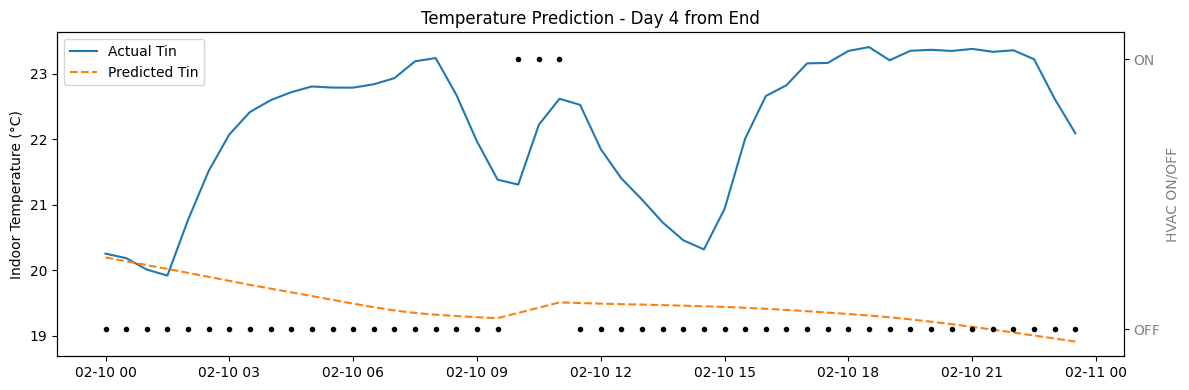

                     total_energy      Tout        Tin         RH  hour  \
timestamp                                                                 
2025-02-11 00:00:00        323.37  2.500000  21.757497  36.423749     0   
2025-02-11 00:30:00        557.63  2.500000  21.418164  36.914398     0   
2025-02-11 01:00:00        375.97  2.400000  21.125778  37.336072     1   
2025-02-11 01:30:00        376.53  2.499444  20.929387  37.364489     1   
2025-02-11 02:00:00        318.87  2.500000  20.760608  37.476451     2   

                     hour_sin  hour_cos  max_Tout  min_Tout  avg_Tout  ...  \
timestamp                                                              ...   
2025-02-11 00:00:00  0.000000  1.000000       7.4       2.0  4.551944  ...   
2025-02-11 00:30:00  0.000000  1.000000       7.4       2.0  4.547778  ...   
2025-02-11 01:00:00  0.258819  0.965926       7.4       2.0  4.545694  ...   
2025-02-11 01:30:00  0.258819  0.965926       7.4       2.0  4.545683  ...   
2025-0

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

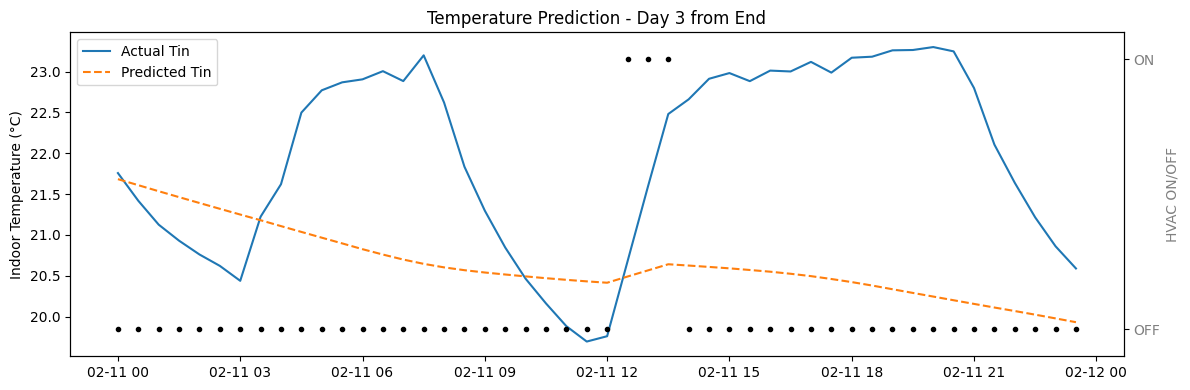

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

                     total_energy      Tout        Tin         RH  hour  \
timestamp                                                                 
2025-02-12 00:00:00        436.83  3.500000  20.324855  36.686121     0   
2025-02-12 00:30:00        331.90  3.400556  20.234497  36.791905     0   
2025-02-12 01:00:00        569.37  3.201111  20.142776  37.354887     1   
2025-02-12 01:30:00        363.87  3.001111  20.852497  36.239389     1   
2025-02-12 02:00:00        467.42  2.900556  21.560941  35.306000     2   

                     hour_sin  hour_cos  max_Tout  min_Tout  avg_Tout  ...  \
timestamp                                                              ...   
2025-02-12 00:00:00  0.000000  1.000000  7.599444  2.001111  4.710185  ...   
2025-02-12 00:30:00  0.000000  1.000000  7.599444  2.001111  4.728946  ...   
2025-02-12 01:00:00  0.258819  0.965926  7.599444  2.001111  4.745636  ...   
2025-02-12 01:30:00  0.258819  0.965926  7.599444  2.001111  4.756087  ...   
2025-0

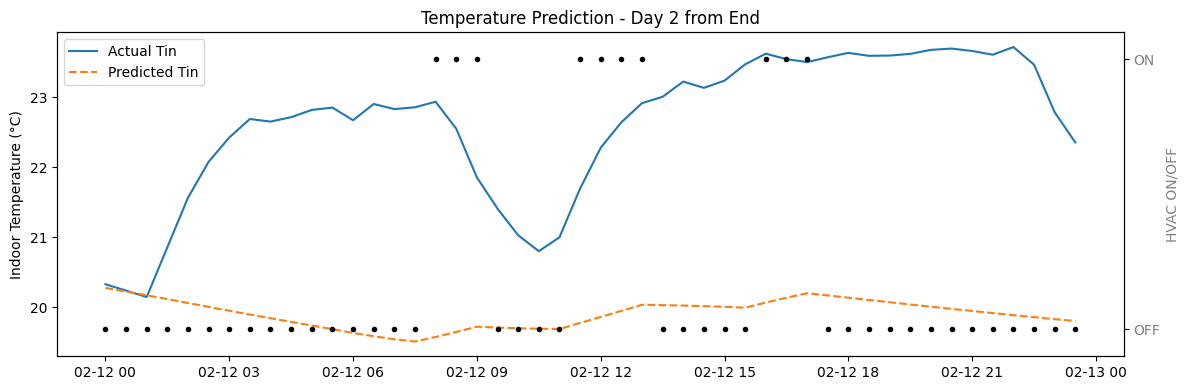

                     total_energy      Tout        Tin         RH  hour  \
timestamp                                                                 
2025-02-13 00:00:00        312.27  5.798889  21.856442  37.600549     0   
2025-02-13 00:30:00        338.73  5.800000  21.653775  37.879525     0   
2025-02-13 01:00:00        362.60  5.800000  21.326775  38.174814     1   
2025-02-13 01:30:00        321.50  5.800000  21.069276  38.391280     1   
2025-02-13 02:00:00        380.00  5.800000  20.939164  38.398838     2   

                     hour_sin  hour_cos  max_Tout  min_Tout  avg_Tout  ...  \
timestamp                                                              ...   
2025-02-13 00:00:00  0.000000  1.000000  8.198889  2.601667  5.426771  ...   
2025-02-13 00:30:00  0.000000  1.000000  8.198889  2.601667  5.476759  ...   
2025-02-13 01:00:00  0.258819  0.965926  8.198889  2.601667  5.530903  ...   
2025-02-13 01:30:00  0.258819  0.965926  8.198889  2.601667  5.589213  ...   
2025-0

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with f

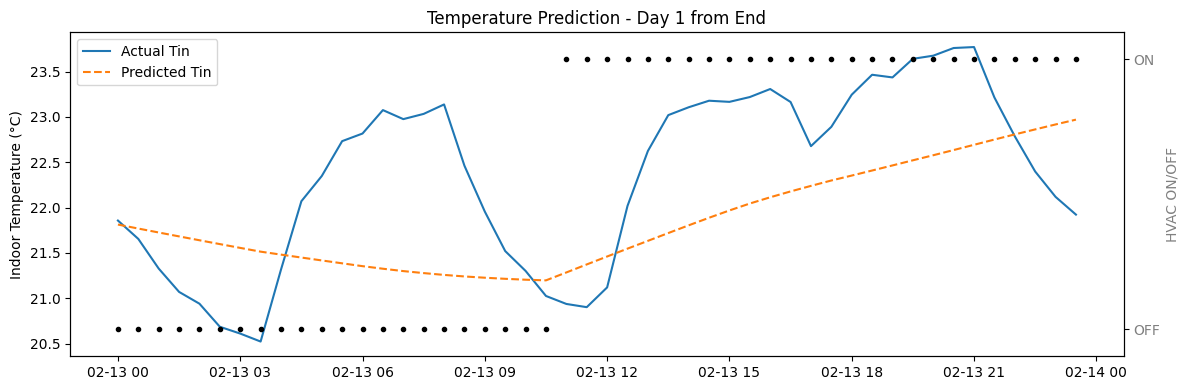

In [42]:
end_date = '2025-02-14'
df = df[df.index < end_date]
df['Tin_next'] = df['Tin'].shift(-1)
df['RH_next'] = df['RH'].shift(-1)
df['Delta_T'] = df['Tin_next'] - df['Tin']
df['Delta_RH'] = df['RH_next'] - df['RH']
df['Tout_minus_Tin'] = df['Tout'] - df['Tin']

# df = df.dropna()

N_test = 48 * 4
df_train = df.iloc[:-N_test]
df_test = df.iloc[-N_test:]

X_temp = df_train[['hvac_on_smooth', 'Tout_minus_Tin']]
y_temp = df_train['Delta_T']
temp_model = LinearRegression().fit(X_temp, y_temp)

X_rh = df_train[['hvac_on_smooth', 'Tout_minus_Tin']]
y_rh = df_train['Delta_RH']
rh_model = LinearRegression().fit(X_rh, y_rh)

N = 48  
start = -1 * (N + 1) 
Tin = df.iloc[start]['Tin']
RH = df.iloc[start]['RH']
schedule = [1] * 24 + [0] * 24 
Tout_series = df.iloc[start:start+N]['Tout'].values

for day in range(4):
    offset = day * 48
    test_chunk = df_test.iloc[offset:offset+48]
    print(test_chunk.head())
    Tin = test_chunk.iloc[0]['Tin']
    RH = test_chunk.iloc[0]['RH']
    timestamps = test_chunk.index.values
    Tout_series = test_chunk['Tout'].values
    HVAC_series =  test_chunk['hvac_on_smooth'].values

    tin_forecast, rh_forecast = [], []
    for i in range(48):
        hvac = HVAC_series[i]
        Tout = Tout_series[i]
        delta_T = temp_model.predict([[hvac, Tout - Tin]])[0]
        delta_RH = rh_model.predict([[hvac, Tout - Tin]])[0]
        Tin += delta_T
        RH += delta_RH
        tin_forecast.append(Tin)
        rh_forecast.append(RH)

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(timestamps, test_chunk['Tin'].values, label='Actual Tin', color='tab:blue')
    ax1.plot(timestamps, tin_forecast, '--', label='Predicted Tin', color='tab:orange')
    ax1.set_ylabel('Indoor Temperature (°C)', color='black')
    ax1.tick_params(axis='y')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(timestamps, HVAC_series, 'ko', label='HVAC Schedule', markersize=3)
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_ylabel('HVAC ON/OFF', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['OFF', 'ON'])

    # plt.title(f'Temperature Forecast vs Actual + HVAC Schedule (Day {4 - day_index_from_end})')
    plt.title(f'Temperature Prediction - Day {4 - day} from End')
    plt.xlabel('Time')
    fig.tight_layout()
    plt.show()